In [1]:
import numpy as np 
import librosa 
import scipy.io as sio
from scipy import signal as sig
import scipy
import torch
import torchaudio.functional as F

Example filter parameters to try

In [2]:
sr = 16000
n_channels = 40 # np.linspace(20, 80, 20) 
lowest_frq = 40 # in Hz
impulse = np.vstack([1, np.zeros((1599,1))]) 


Port over Slaney's Audio Toolbox functions 

8/25/2021 - These are producing the same results as Slaney's Matlab functions! 

In [3]:
def ERB_space(lowFreq=100, highFreq=44100/4, N=100):
    '''
    Python port from Malcom Slaney's Audio Toolbox 
    Port by Ian Griffith. August 24, 2021. 

    This function computes an array of N frequencies uniformly spaced between
    highFreq and lowFreq on an ERB scale.  N is set to 100 if not specified.

    See also linspace, logspace, MakeERBCoeffs, MakeERBFilters.

    For a definition of ERB, see Moore, B. C. J., and Glasberg, B. R. (1983).
    "Suggested formulae for calculating auditory-filter bandwidths and
    excitation patterns," J. Acoust. Soc. Am. 74, 750-753.'''


    # Change the following three parameters if you wish to use a different
    # ERB scale.  Must change in MakeERBCoeffs too.
    EarQ = 9.26449            #  Glasberg and Moore Parameters
    minBW = 24.7
    order = 1
#     print(highFreq)
    # All of the followFreqing expressions are derived in Apple TR #35, "An
    # Efficient Implementation of the Patterson-Holdsworth Cochlear
    # Filter Bank."  See pages 33-34.
    freq_ixs = np.arange(N).reshape(1,-1) + 1 # +1 to match matlab (1:N) construction
    
    cfArray = -(EarQ*minBW) + np.exp(freq_ixs.T * (-np.log(highFreq + EarQ*minBW) + 
            np.log(lowFreq + EarQ*minBW))/ N) * (highFreq + EarQ*minBW)
    return cfArray

def make_ERB_filters(fs,numChannels,lowFreq):
    ''' 
     Python port from Malcom Slaney's Audio Toolbox 
     Port by Ian Griffith. August 24, 2021. 
     
     This function computes the filter coefficients for a bank of 
     Gammatone filters.  These filters were defined by Patterson and 
     Holdworth for simulating the cochlea.  

     The result is returned as an array of filter coefficients.  Each row 
     of the filter arrays contains the coefficients for four second order 
     filters.  The transfer function for these four filters share the same
     denominator (poles) but have different numerators (zeros).  All of these
     coefficients are assembled into one vector that the ERBFilterBank 
     can take apart to implement the filter.

     The filter bank contains "numChannels" channels that extend from
     half the sampling rate (fs) to "lowFreq".  Alternatively, if the numChannels
     input argument is a vector, then the values of this vector are taken to
     be the center frequency of each desired filter.  (The lowFreq argument is
     ignored in this case.)
    '''
    
    t = 1/fs
           
    # cf is array of center frequencies 
#     print(lowFreq)
    
    if isinstance(numChannels, np.ndarray):
        cf = numChannels[1:]
        if cf.shape[1] > cf.shape[0]:
            cf = cf.T
    else:
         cf = ERB_space(lowFreq, fs/2, numChannels) 
            
            
    # Change the followFreqing three parameters if you wish to use a different
    # ERB scale.  Must change in ERBSpace too.
    earQ = 9.26449        #  Glasberg and Moore Parameters
    minBW = 24.7
    order = 1
    
    erb = (((cf/earQ)**order) + minBW ** order) ** (1/order)
    b=1.019*2*np.pi*erb
    
    a0 = t
    a2 = 0
    b0 = 1
    b1 = -2*np.cos(2*cf*np.pi*t)/np.exp(b*t)
    b2 = np.exp(-2*b*t)
    
    
    a11 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) + 2*np.sqrt(3+2**1.5)*t*np.sin(2*cf*np.pi*t)/
            np.exp(b*t))/2
    a12 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) - 2*np.sqrt(3+2**1.5)*t*np.sin(2*cf*np.pi*t)/ 
            np.exp(b*t))/2
    a13 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) + 2*np.sqrt(3-2**1.5)*t*np.sin(2*cf*np.pi*t)/ 
            np.exp(b*t))/2
    a14 = -(2*t*np.cos(2*cf*np.pi*t)/np.exp(b*t) - 2*np.sqrt(3-2**1.5)*t*np.sin(2*cf*np.pi*t)/ 
            np.exp(b*t))/2

    gain = abs((-2*np.exp(4*1j*cf*np.pi*t)*t + 
                     2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
                             (np.cos(2*cf*np.pi*t) - np.sqrt(3 - 2**(3/2))* 
                              np.sin(2*cf*np.pi*t))) * 
               (-2*np.exp(4*1j*cf*np.pi*t)*t + 
                 2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
                  (np.cos(2*cf*np.pi*t) + np.sqrt(3 - 2**(3/2)) * 
                   np.sin(2*cf*np.pi*t)))* 
               (-2*np.exp(4*1j*cf*np.pi*t)*t + 
                 2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
                  (np.cos(2*cf*np.pi*t) - 
                   np.sqrt(3 + 2**(3/2))*np.sin(2*cf*np.pi*t))) * 
               (-2*np.exp(4*1j*cf*np.pi*t)*t + 2*np.exp(-(b*t) + 2*1j*cf*np.pi*t)*t* 
               (np.cos(2*cf*np.pi*t) + np.sqrt(3 + 2**(3/2))*np.sin(2*cf*np.pi*t))) / 
              (-2 / np.exp(2*b*t) - 2*np.exp(4*1j*cf*np.pi*t) +  
               2*(1 + np.exp(4*1j*cf*np.pi*t))/np.exp(b*t))**4)
    allfilts = np.ones((max(cf.shape),1)) 
    fcoefs = np.hstack([a0*allfilts, a11, a12, a13, a14, a2*allfilts, b0*allfilts, b1, b2, gain])
    return fcoefs , cf

def apply_ERB_filter_bank(x, fcoefs):
    '''
    Process an input waveform with a gammatone filter bank. This function
    takes a single sound vector, and returns an array of filter outputs, one
    channel per row.

    The fcoefs parameter, which completely specifies the Gammatone filterbank,
    should be designed with the MakeERBFilters function.  If it is omitted,
    the filter coefficients are computed for you assuming a 22050Hz sampling
    rate and 64 filters regularly spaced on an ERB scale from fs/2 down to 100Hz.


    Malcolm Slaney @ Interval, June 11, 1998.
    (c) 1998 Interval Research Corporation
    Thanks to Alain de Cheveigne' for his suggestions and improvements.
    '''
    # if nargin < 1
    # 	error('Syntax: output_array = ERBFilterBank(input_vector[, fcoefs]);');
    # end
    #
    # if nargin < 2
    # 	fcoefs = MakeERBFilters(22050,64,100);
    # end

    if fcoefs.shape[1] != 10:
        raise ValueError('fcoefs parameter passed to ERBFilterBank is the wrong size.')

    if x.ndim > 1 and x.shape[1] < x.shape[0]:
        x = x.T
        print('x is transposed')
        
    signal_length = max(x.shape)
    
    A0  = fcoefs[:,0]
    A11 = fcoefs[:,1]
    A12 = fcoefs[:,2]
    A13 = fcoefs[:,3]
    A14 = fcoefs[:,4]
    A2  = fcoefs[:,5]
    B0  = fcoefs[:,6]
    B1  = fcoefs[:,7]
    B2  = fcoefs[:,8]
    gain= fcoefs[:,9]

    output = np.zeros((len(gain), signal_length))
    print(output.shape)
    x = np.squeeze(x)
#     print(x.shape)
    for chan in range(len(gain)): #
    # Note here, matlab implementation passes A coefficients into B arguement
    # and vice versa - is this a bug or correct? 
        y1 = sig.lfilter(
            [A0[chan]/gain[chan], A11[chan]/gain[chan], A2[chan]/gain[chan]],
            [B0[chan], B1[chan], B2[chan]], x)
        y2 = sig.lfilter(
            [A0[chan], A12[chan], A2[chan]],
            [B0[chan], B1[chan], B2[chan]], y1)
        y3 = sig.lfilter(
            [A0[chan], A13[chan], A2[chan]],
            [B0[chan], B1[chan], B2[chan]], y2)
        y4 = sig.lfilter(
            [A0[chan], A14[chan], A2[chan]],
            [B0[chan], B1[chan], B2[chan]], y3)
#         if chan==0:
#             print(x.shape, y1.shape,y2.shape,y3.shape,y4.shape)
        output[chan, :] = y4

    return output


def backend_hann2d(x, ramp_dur_ms, samplerate=48000):
    stim_dur_smp = x.shape[1] # N taps of x
    ramp_dur_smp =  np.floor(ramp_dur_ms * samplerate / 1000).astype('int')
    assert stim_dur_smp > (2*ramp_dur_smp), 'Ramps cannot be longer than the stimulus duration'
    
    # calc window
    # https://stackoverflow.com/questions/56485663/hanning-window-values-doesnt-match-in-python-and-matlab
    win = sig.hann((2 * ramp_dur_smp) + 2)[1:-1]
    
    # Middle part (steady state)
    steady_win = x[:,:stim_dur_smp-ramp_dur_smp]
    
    # Final part of windowed stimulus
    end_win = win[ramp_dur_smp : ramp_dur_smp*2] * x[:, stim_dur_smp-ramp_dur_smp:stim_dur_smp]

    return np.hstack([steady_win, end_win])

    

In [4]:
# @torch.jit.script
def pytorch_ERB_filter_bank(x: torch.Tensor, fcoefs: torch.Tensor) -> torch.Tensor:
    r"""Processes a wavform with an ERB filter bank using an IIR filter.
    
    Args:
        x (torch.Tensor): with shape `(Batch, Channels, Time)`.
        fcoefs (torch.Tensor): tensor of ERB filterbank coefficients
            with shape '(n_channels, 10)'.

    Returns:
        (torch.Tensor):
            torch.Tensor
                y, with shape `(Batch, Channels, Time)`.

    """
    

    if fcoefs.shape[1] != 10:
        raise ValueError('fcoefs parameter passed to ERBFilterBank is the wrong size.')
    
    a1 = fcoefs[:, [0,1,5]]
    a2 = fcoefs[:, [0,2,5]]
    a3 = fcoefs[:, [0,3,5]]
    a4 = fcoefs[:, [0,4,5]]

    b_coefs = fcoefs[:,[6,7,8]]
    
    gain = fcoefs[:,9].unsqueeze(1)

    # Apply cascade of low-pass filters 
    # for ref on clamp and batching args:
    # https://pytorch.org/audio/0.10.0/functional.html#lfilter 
    # Current settings match output from matlab and numpy implementations
    
    # Note: following Slaney implementation where b = A and a = B 
    # in lfilter input args 
    y = F.lfilter(x, b_coefs, 
                 torch.div(a1, gain), clamp=False, batching=False)

    y = F.lfilter(y, b_coefs, a2, clamp=False, batching=True)

    y = F.lfilter(y, b_coefs, a3, clamp=False, batching=True)

    y = F.lfilter(y, b_coefs, a4, clamp=False, batching=True)

    return y # remove extra dim added by lfilter


In [5]:
%matplotlib inline 

import matplotlib.pyplot as plt 
from matplotlib import cm

In [6]:
erb_coefs,cf = make_ERB_filters(sr, n_channels, lowest_frq)

In [7]:
erb_coefs.shape

torch_coefs = torch.from_numpy(erb_coefs)

torch_impulse = torch.from_numpy(impulse)


impulses = torch.stack([torch_impulse, torch_impulse], 2).transpose(0,2)

In [8]:
impulses.squeeze().shape

torch.Size([2, 1600])

In [9]:
gain =  torch_coefs[:,9].unsqueeze(1)

b_coefs = torch_coefs[:,[6,7,8]]


torch_ir = F.lfilter(impulses, b_coefs, 
                     torch.div(torch_coefs[:, [0,1,5]], gain), clamp=False, batching=False)

torch_ir = F.lfilter(torch_ir, b_coefs, 
                     torch_coefs[:, [0,2,5]], clamp=False, batching=True)

torch_ir = F.lfilter(torch_ir, b_coefs, 
                     torch_coefs[:, [0,3,5]], clamp=False, batching=True)

torch_ir = F.lfilter(torch_ir, b_coefs, 
                     torch_coefs[:, [0,4,5]], clamp=False, batching=True)

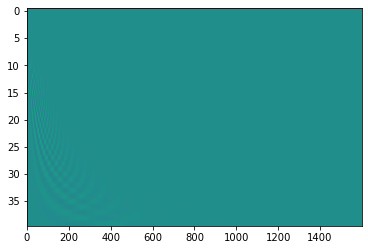

In [10]:
plt.imshow(torch_ir.numpy()[0,0,...], aspect='auto')

In [11]:
torch_i2 = pytorch_ERB_filter_bank(torch_impulse.T, torch_coefs)

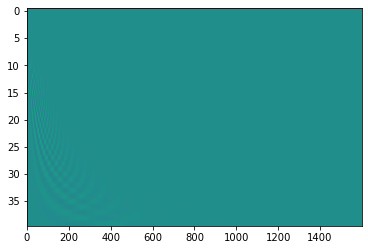

In [12]:
plt.imshow(torch_i2.numpy()[0,...], aspect='auto')

In [13]:
y_py = apply_ERB_filter_bank(impulse, erb_coefs)

x is transposed
(40, 1600)


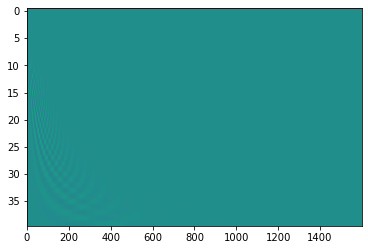

In [14]:
plt.imshow(y_py, aspect='auto')

In [15]:
np.isclose(y_py,torch_ir.numpy()[1,0,...]).all()

True

In [16]:
np.isclose(y_py,torch_i2.numpy().squeeze()).all()

True

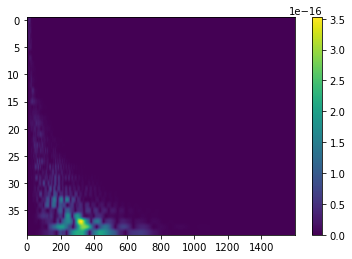

In [17]:
diff = abs(torch_ir.numpy()[0,0,...] - y_py )
plt.imshow(diff, aspect='auto' )
plt.colorbar()


In [15]:

window_size = 10

ir = backend_hann2d(y_py, window_size, sr)
ir.shape

(40, 1600)

In [16]:
torch_ir =  backend_hann2d(torch_i2.numpy().squeeze(), window_size, sr)

In [17]:
np.isclose(torch_ir, ir).all()

True

Text(0.5, 0, 'Channel')

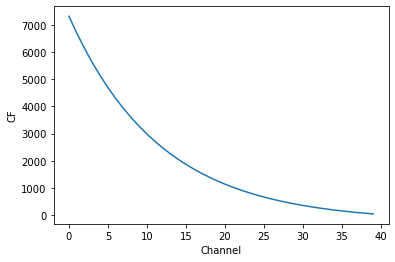

In [23]:
plt.plot(cf)
plt.ylabel('CF')
plt.xlabel('Channel')

Check if implementation is same. Compare python coefficients to matlab coefficients 

In [24]:
mat_coef_file = sio.loadmat('../../cocktail_party/erbcoefs_40_filt.mat')
mat_coefs = mat_coef_file['erbcoefs']

In [25]:
np.isclose(mat_coefs,erb_coefs).all()

True

In [26]:
diff = abs(mat_coefs.astype('float64')  - erb_coefs )

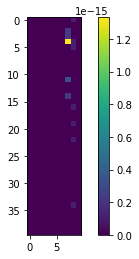

In [27]:
plt.imshow(diff )
plt.colorbar()


In [28]:
y_py.shape

(40, 1600)

In [29]:
y_py.shape

(40, 1600)

In [30]:
y_mat = apply_ERB_filter_bank(impulse, mat_coefs)

x is transposed
(40, 1600)


In [31]:
from scipy.fft import fft 

In [32]:
py_resp = 20*(np.log10(abs(fft(y_py)))) # Note, no transpose before fft in python - can apply after for same dims

In [33]:
mat_resp = 20*np.log10(np.abs(fft(y_mat)))

In [34]:
torch_resp = 20*np.log10(np.abs(fft(torch_i2.numpy().squeeze())))

In [35]:
np.isclose(mat_resp,py_resp).all()

True

In [36]:
np.isclose(mat_resp,torch_resp).all()

True

Text(0.5, 1.0, 'Filter Frequency response - Numpy coefs')

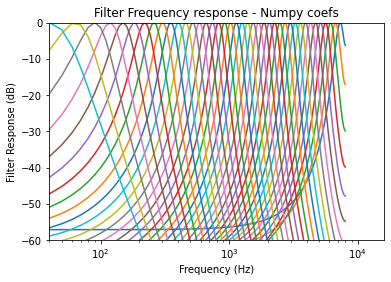

In [37]:
sig_len = len(impulse)
cutoff= sig_len//2

freqScale = np.arange(sig_len)/sig_len*16000 

plt.semilogx(freqScale[0:cutoff], py_resp.T[0:cutoff,:]);
plt.axis([lowest_frq, sr, -60, 0])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Filter Response (dB)')
plt.title('Filter Frequency response - Numpy coefs')

Text(0.5, 1.0, 'Filter Frequency response - Matlab coefs')

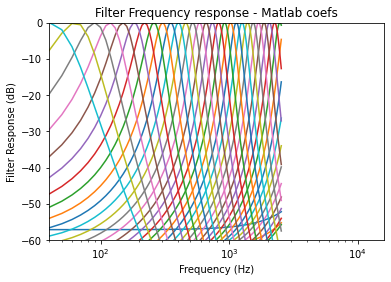

In [38]:
plt.semilogx(freqScale[0:255], mat_resp.T[0:255,:])
plt.axis([lowest_frq, sr, -60, 0])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Filter Response (dB)')
plt.title('Filter Frequency response - Matlab coefs')

Text(0.5, 1.0, 'Filter Frequency response - torchaudio coefs')

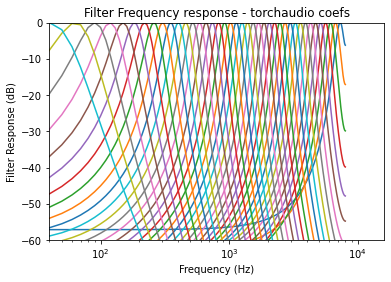

In [39]:
plt.semilogx(freqScale[0:cutoff], torch_resp.T[0:cutoff,:]);
plt.axis([lowest_frq, sr, -60, 0])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Filter Response (dB)')
plt.title('Filter Frequency response - torchaudio coefs')

### Compare windowed impulse responses between matlab and python implementation

In [18]:
py_ir = ir 

mat_ir_path = '../../cocktail_party/deepspeech/cochlear_filter_impulse_response_40_channels_16k_taps_10ms_hann_win.mat'

mat_ir = sio.loadmat(mat_ir_path)['IR']


True

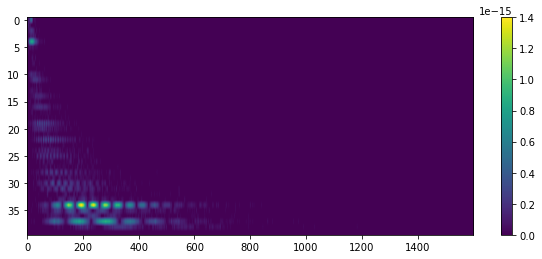

In [25]:

plt.figure(figsize=(10,4))
diff_y = abs(py_ir.round(16) - mat_ir.round(16))
plt.imshow(diff_y, aspect='auto')
plt.colorbar()
np.isclose(py_ir, mat_ir).all()

True

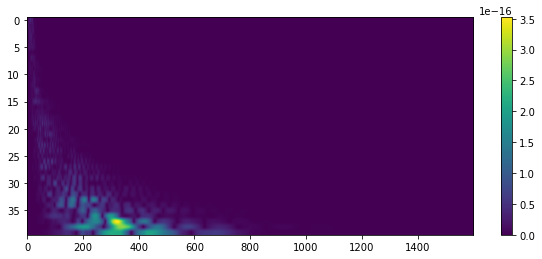

In [32]:

plt.figure(figsize=(10,4))
diff_y = abs(torch_ir - py_ir)
plt.imshow(diff_y, aspect='auto')
plt.colorbar()
np.isclose(torch_ir, mat_ir).all()


## Apply to a sentence 


In [19]:
from datasets import load_dataset # huggingface api
import torchaudio

path = '/om2/data/public/GigaSpeech/data/XL_munged.csv'

dataset = load_dataset('csv', data_files=path, split='train')



Using custom data configuration default-57731ec938d8e394
Reusing dataset csv (/home/imgriff/.cache/huggingface/datasets/csv/default-57731ec938d8e394/0.0.0/6b9057d9e23d9d8a2f05b985917a0da84d70c5dae3d22ddd8a3f22fb01c69d9e)


In [23]:
eg = 1000000
SAMPLING_RATE = 16000


wavs = []
texts = []
for eg in range(1000000, 1000016):
    item = dataset[eg]

    name = item['wav_filename']
            # get wav path
    wav_path = item['wav_path']
    # get excertp frames 
    start = int(float(item['start']) * SAMPLING_RATE)
    end = int(float(item['end']) * SAMPLING_RATE)
    num_frames = end - start 
    # Load wav excerpt 
    wav, _ = torchaudio.load(wav_path,
                            frame_offset = start,
                            num_frames = num_frames)
    text = item['transcript']
    wavs.append(wav)
    texts.append(text)

In [24]:
max_len = max([max(wav.shape) for wav in wavs])

wav_tensor = torch.zeros((len(wavs), max_len))
for i,wav in enumerate(wavs):
    wav_dur = wav.size(1)
    wav_tensor[i, : wav_dur] = wav.squeeze()

In [25]:
wav_tensor.shape

torch.Size([16, 33600])

In [48]:
processed = pytorch_ERB_filter_bank(wav.type(torch.DoubleTensor), torch_coefs)

In [49]:
processed.shape

torch.Size([1, 40, 22880])

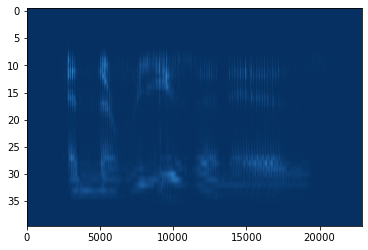

In [50]:
plt.imshow(torch.nn.functional.relu(processed.squeeze()), cmap=cm.RdBu_r,aspect='auto')


In [51]:
np_processed = apply_ERB_filter_bank(wav.numpy(), erb_coefs)

(40, 22880)


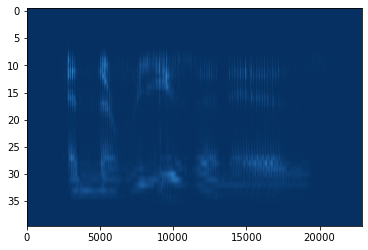

In [57]:
plt.imshow( np_processed * (np_processed > 0) , cmap=cm.RdBu_r,aspect='auto')


In [26]:
import sys
sys.path.append('/om/user/imgriff/python-packages/chcochleagram/')


In [27]:
import chcochleagram
import chcochleagram.compression as compression
import chcochleagram.downsampling as downsampling

In [28]:
cochlea_filt = {'rep_type': 'cochlea_filt',
                 'rep_kwargs': {'sr':16000,
                                'env_sr': 8000,
                                'env_extraction_type': 'Half-wave Rectification',
                                'downsampling_type': downsampling.SincWithKaiserWindow,
                                'downsampling_kwargs': {
                                    'window_size':1001},
                               },
                 'compression_type': 'coch_p3',
                 'compression_kwargs': {'scale': 1,
                                        'offset':1e-8,
                                        'clip_value':5, # This wil clip cochleagram values < ~0.04
                                        'power': 0.3}
                }


In [29]:
downsample_fn = downsampling.SincWithKaiserWindow
downsampling_op = downsample_fn(16000, 8000, window_size=1001)

In [30]:
downsampling_op.downsample_filter.type()

'torch.FloatTensor'

In [31]:
compression_op = compression.ClippedGradPowerCompression(**cochlea_filt['compression_kwargs'])

#### Full pytorch rep of sound

In [32]:
class GammaToneFilter(torch.nn.Module):

    def __init__(self, coefs, scale=1, offset=1e-8, clip_value=5, power=0.3 ):
        super(GammaToneFilter, self).__init__()

        downsample_fn = downsampling.SincWithKaiserWindow
        self.downsampling_op = downsample_fn(16000, 8000, window_size=1001)
        self.compression_op = compression.ClippedGradPowerCompression(scale=scale,
                                                                      offset=offset,
                                                                      clip_value=clip_value,
                                                                      power=power)
        self.register_buffer("coefs", coefs.type(torch.FloatTensor))
        
        self.apply_fn = pytorch_ERB_filter_bank
        
#     @torch.jit.script_method
    def forward(self, x):
        x = self.apply_fn(x, self.coefs)
        x = torch.nn.functional.relu(x, inplace=True)
        x = self.compression_op(x)
        x = self.downsampling_op(x)
        return x 

        

In [33]:
%%timeit
processed = pytorch_ERB_filter_bank(wav_tensor, torch_coefs.type(torch.FloatTensor))
processed = torch.nn.functional.relu(processed)
processed = compression_op(processed)
processed = downsampling_op(processed)


3.22 s ± 47.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [80]:
downsampling_op.cpu()

SincWithKaiserWindow()

In [34]:
coch_filt = torch.from_numpy(np.expand_dims(mat_ir, 1)).type(torch.FloatTensor)
coch_filt = coch_filt.cuda()

In [35]:
wav_tens_ = wav_tensor.cuda()

In [36]:
cuda_downsamp = downsampling_op.cuda()

In [37]:
%%timeit

proc2 = torch.nn.functional.conv1d(wav_tens_.view(3,1,-1), coch_filt, padding='same')
proc2 = torch.nn.functional.relu(proc2)
proc2 = compression_op(proc2)
proc2 = cuda_downsamp(proc2)

303 µs ± 17.4 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


<magic-timeit>:1: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at  /opt/conda/conda-bld/pytorch_1639180549130/work/aten/src/ATen/native/Convolution.cpp:647.)


In [52]:
proc2.shape

torch.Size([3, 40, 28800])

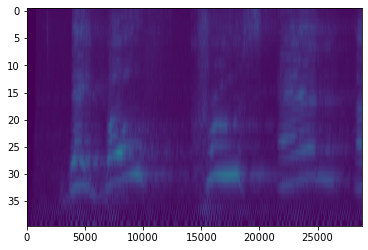

In [55]:
plt.imshow(proc2.cpu().numpy()[0,...]**0.3, aspect='auto')

In [ ]:
filter_op = GammaToneFilter(torch_coefs)

In [ ]:
%%timeit
processed = filter_op(wav_tensor)

In [ ]:
plt.imshow(processed[1].squeeze(), cmap=cm.RdBu_r, aspect='auto')


In [ ]:
texts[1]

In [ ]:
from IPython.display import Audio

In [ ]:
Audio(wavs[1].numpy(), rate=16000)

In [ ]:
wav.size(1)/SAMPLING_RATE

In [ ]:
processed.size(-1)/ (SAMPLING_RATE/2)